In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pvlib

In [2]:
# Weather File for Richmond, VA
wf = '724010TYA.CSV'

# Read the CSV file
df = pd.read_csv(wf, skiprows=1)

# Rename columns for easier reference
date_col = "Date (MM/DD/YYYY)"
time_col = "Time (HH:MM)"

# Convert Date column to datetime format
df[date_col] = pd.to_datetime(df[date_col], format="%m/%d/%Y", errors="coerce")

# Fix "24:00" by replacing it with "00:00" and shifting the date forward
mask = df[time_col] == "24:00"
df.loc[mask, time_col] = "00:00"
df.loc[mask, date_col] = df.loc[mask, date_col] + pd.Timedelta(days=1)

# **Now remove February 29**
df = df[~((df[date_col].dt.month == 2) & (df[date_col].dt.day == 29))]

# Convert back to string format for merging with Time column
df[date_col] = df[date_col].dt.strftime("%m/%d/%Y")

# Combine Date and Time into a single DateTime column
df["DateTime"] = pd.to_datetime(df[date_col] + " " + df[time_col], format="%m/%d/%Y %H:%M")

# Normalize all years to 2025
df["DateTime"] = df["DateTime"].apply(lambda x: x.replace(year=2025))

# Set DateTime as index
df.set_index("DateTime", inplace=True)

# Optionally drop the original Date and Time columns
df.drop(columns=[date_col, time_col], inplace=True)

# Drop columns that I won't need
df = df[['DNI (W/m^2)','DHI (W/m^2)','GHI (W/m^2)']]

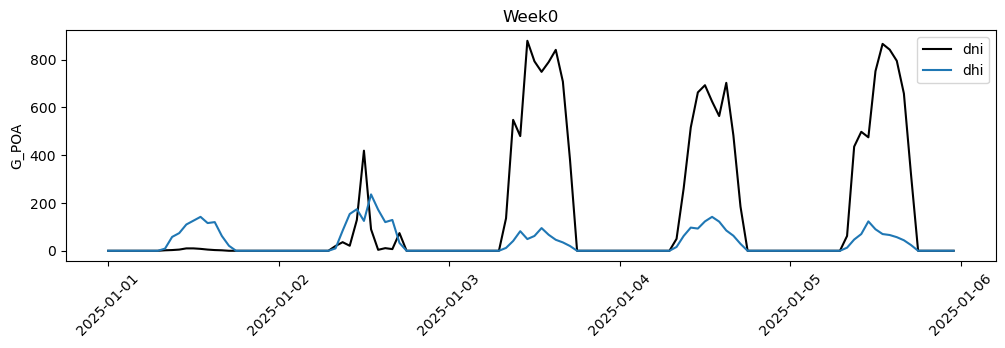

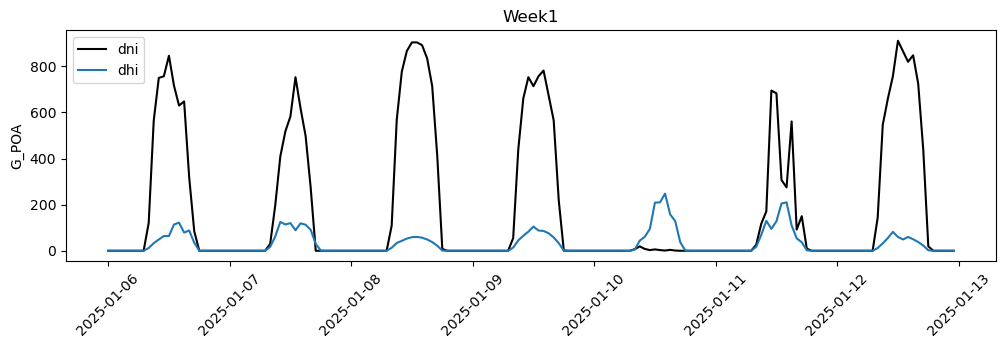

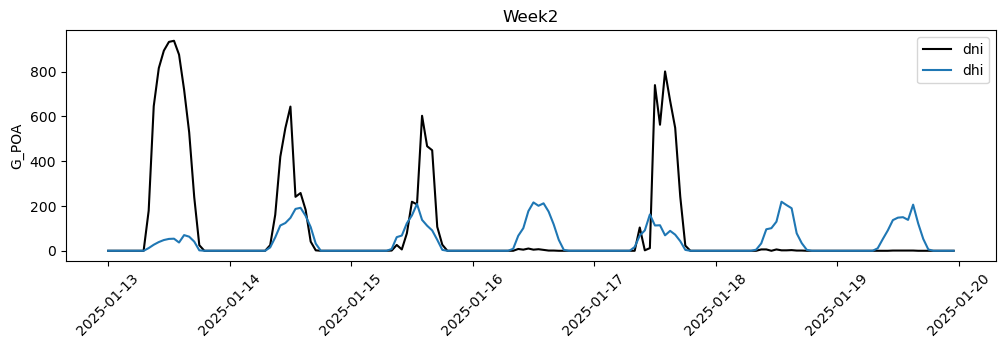

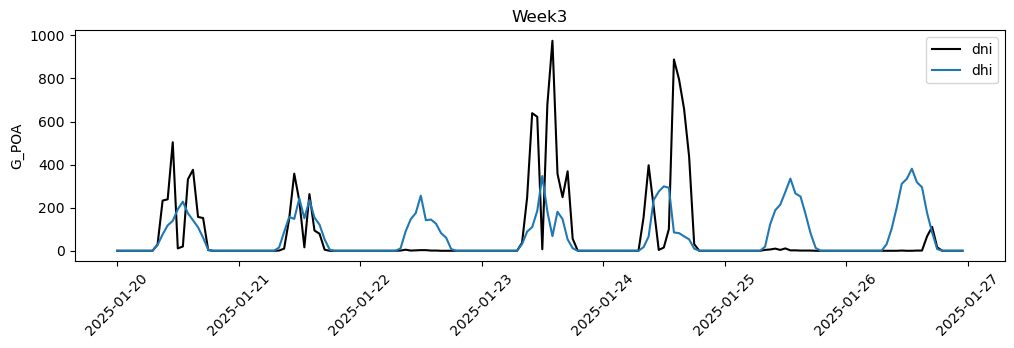

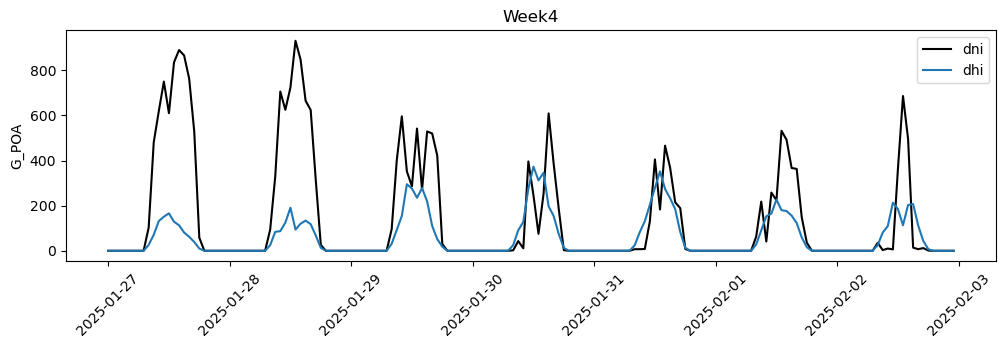

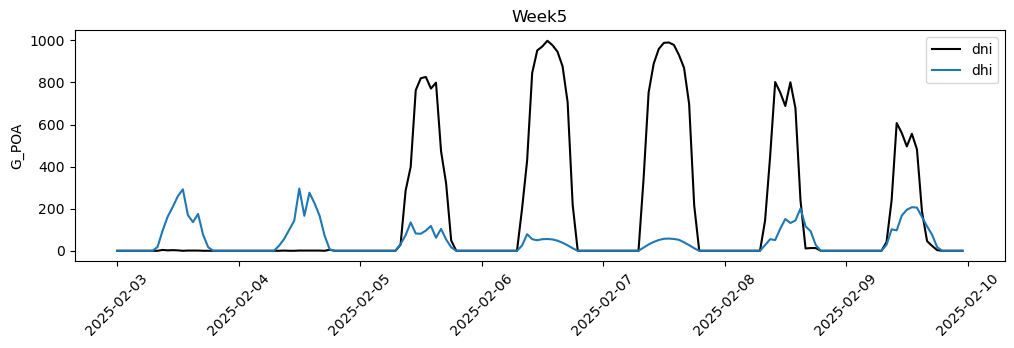

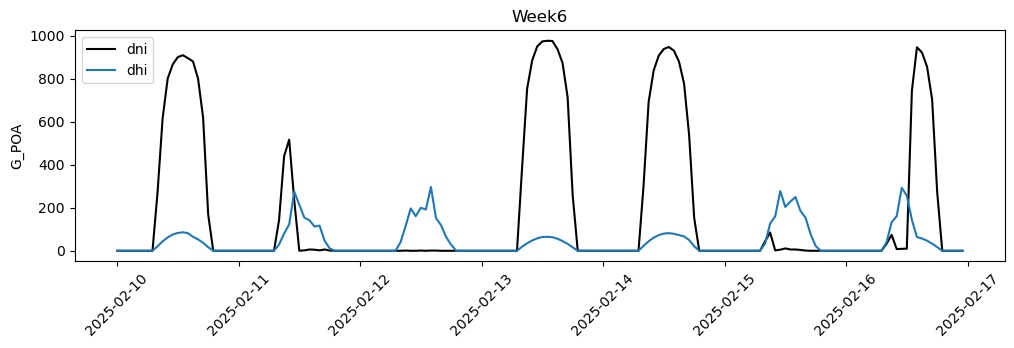

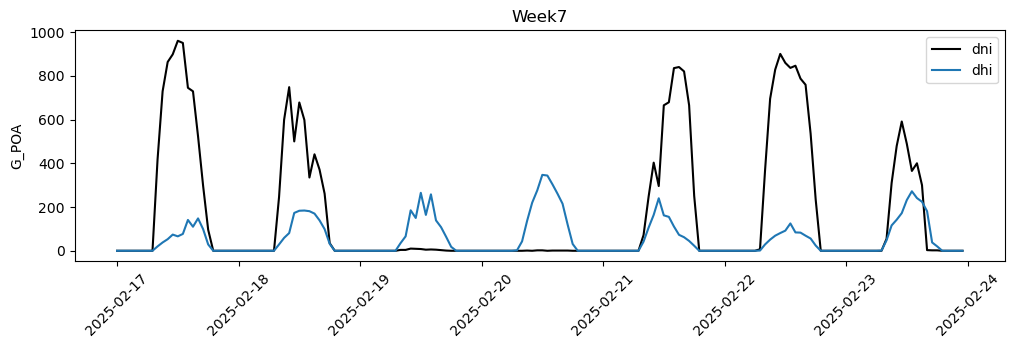

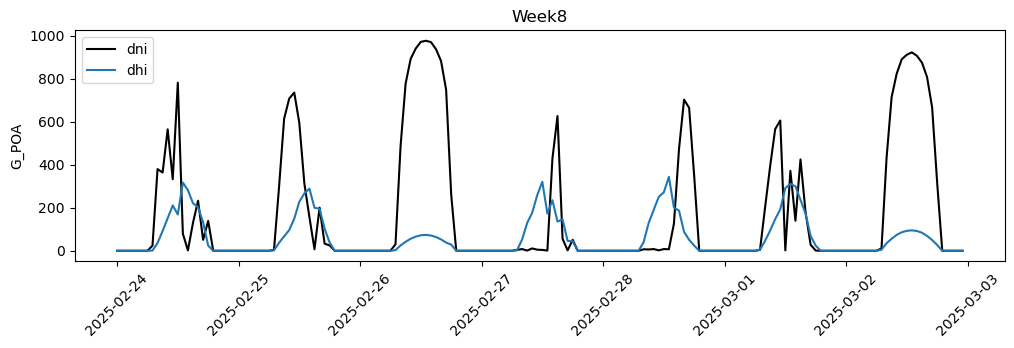

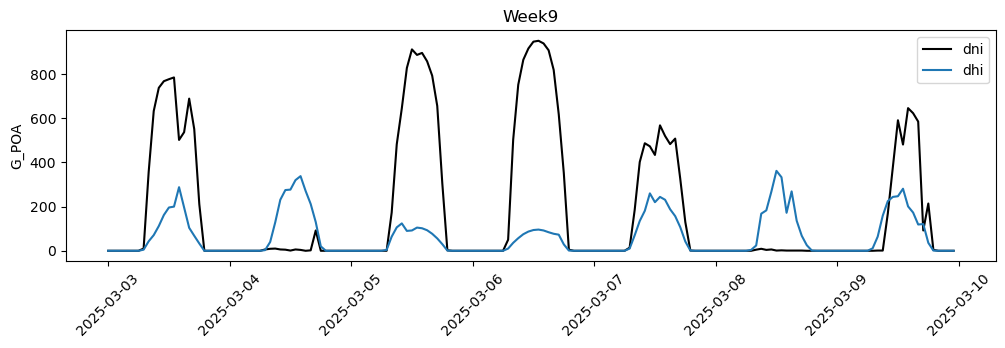

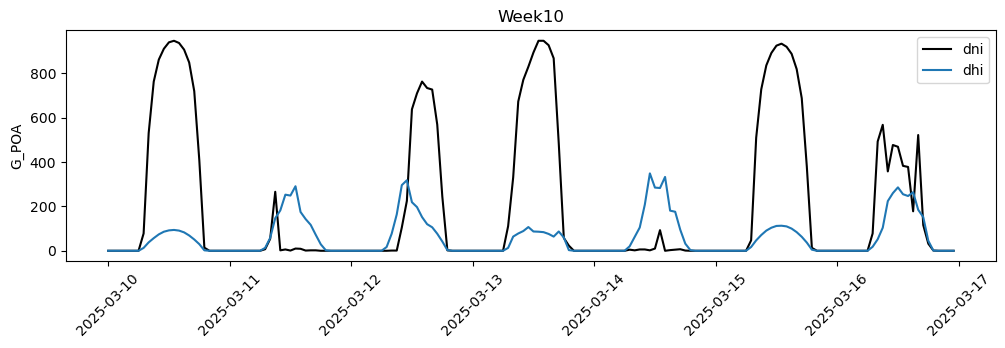

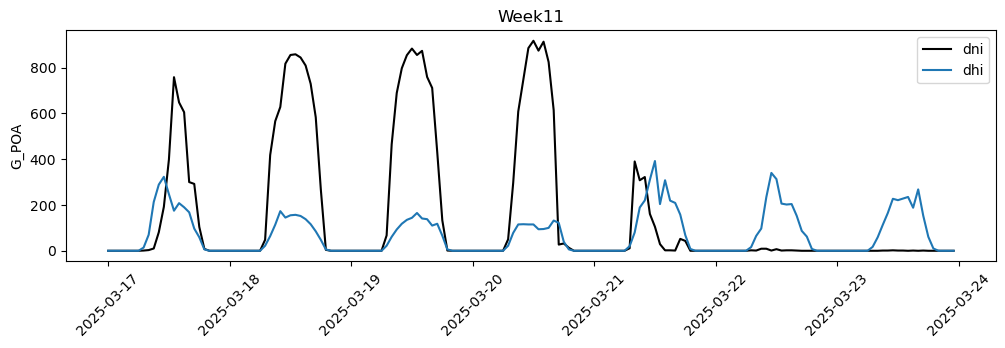

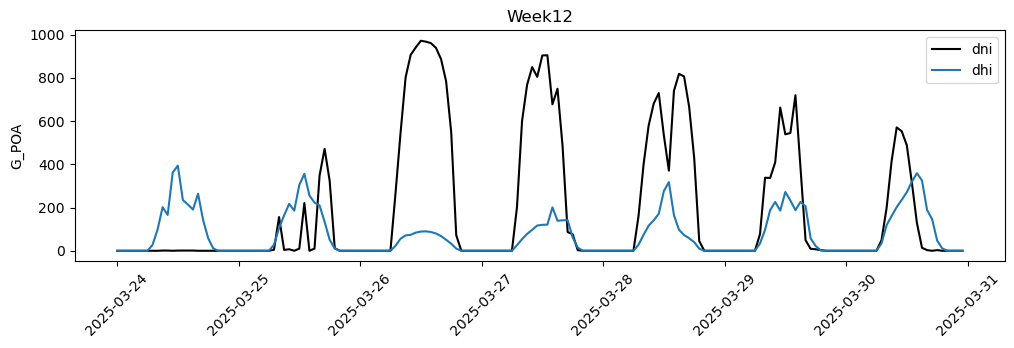

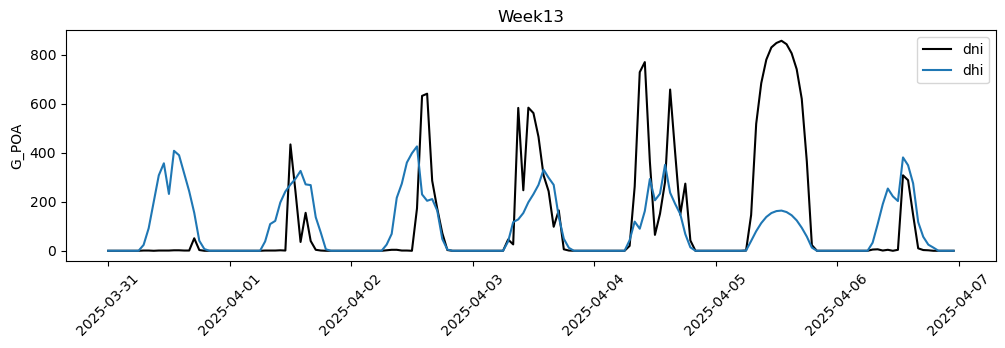

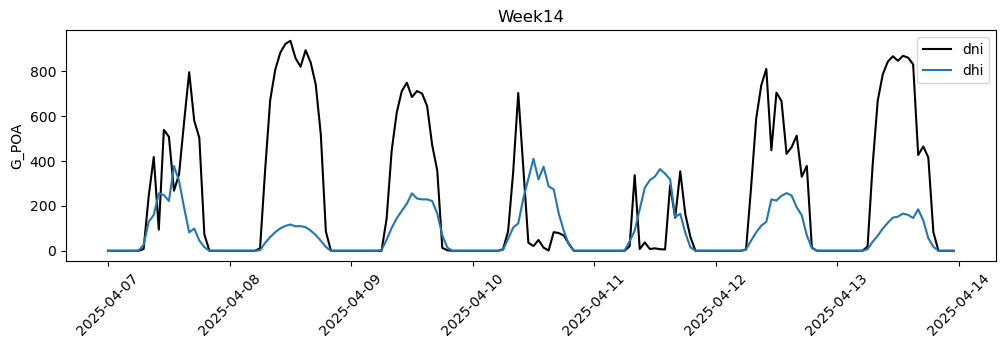

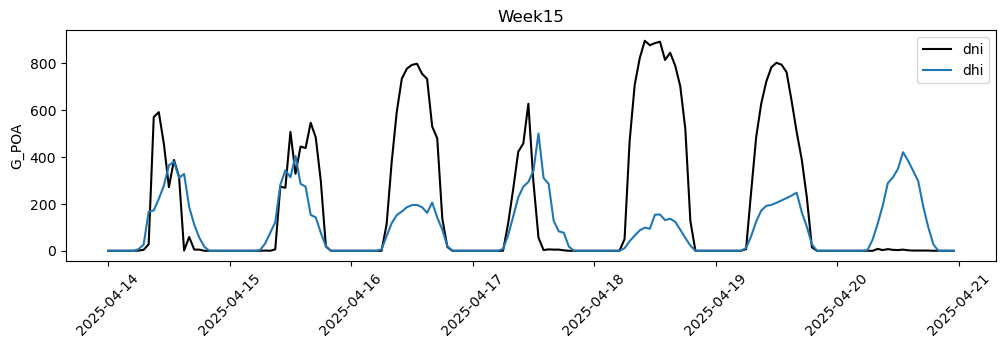

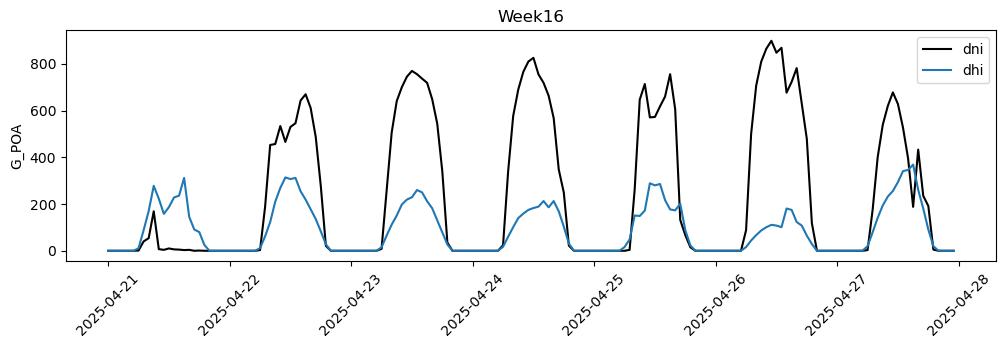

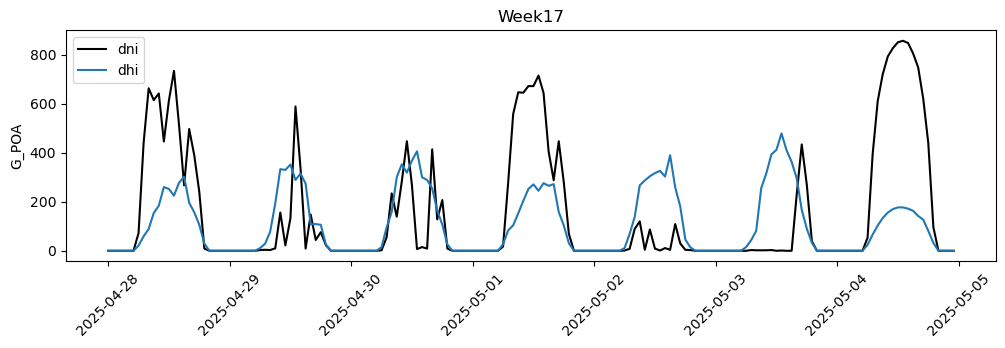

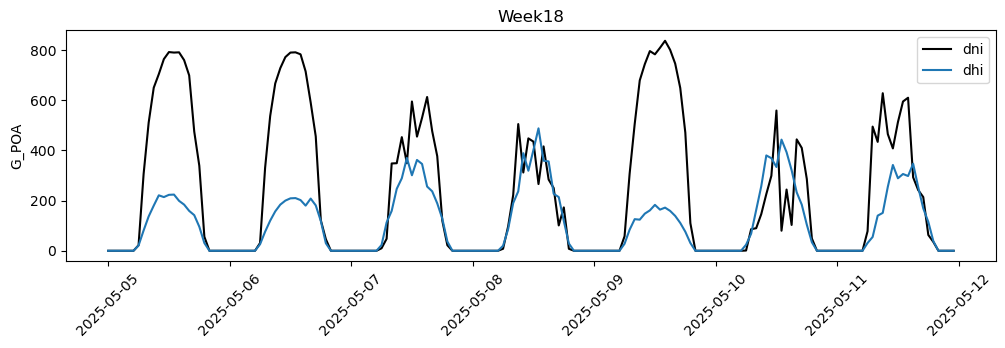

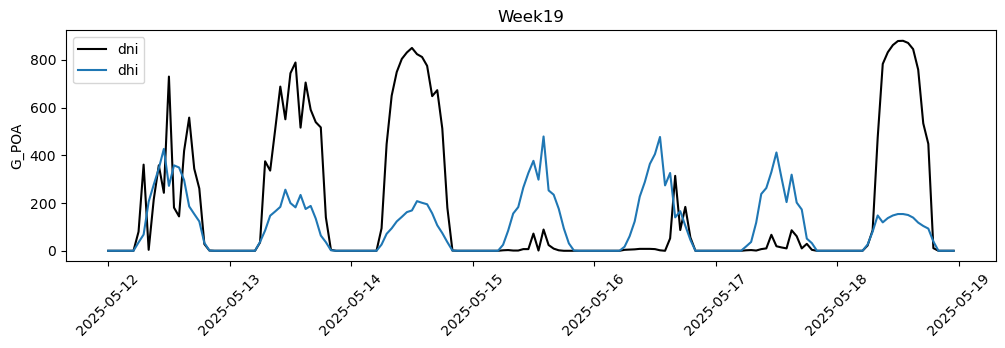

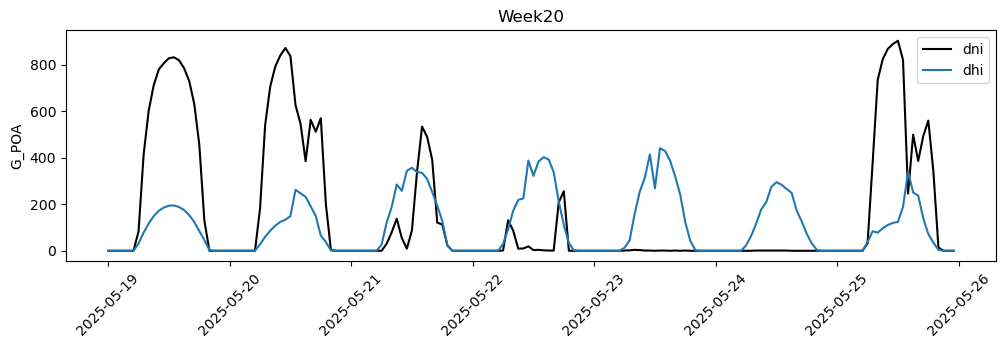

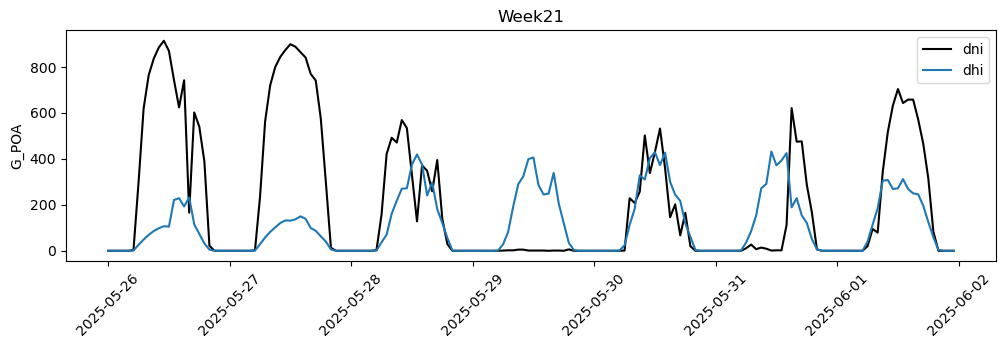

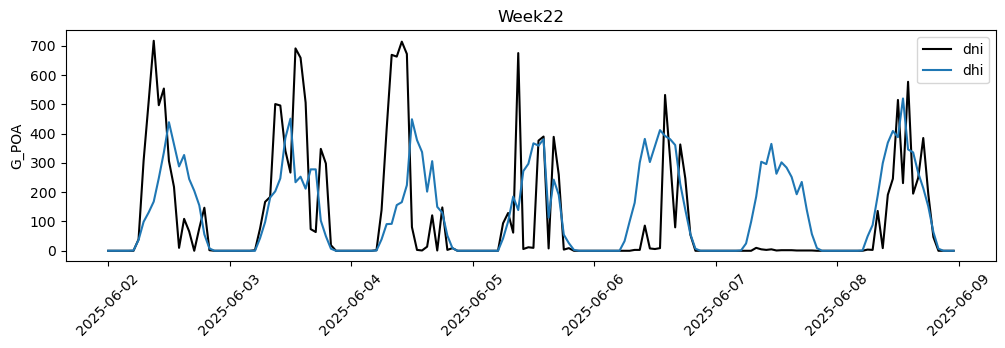

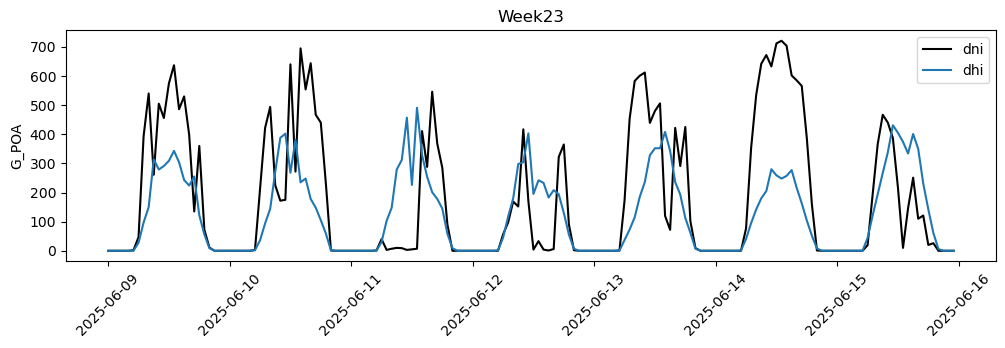

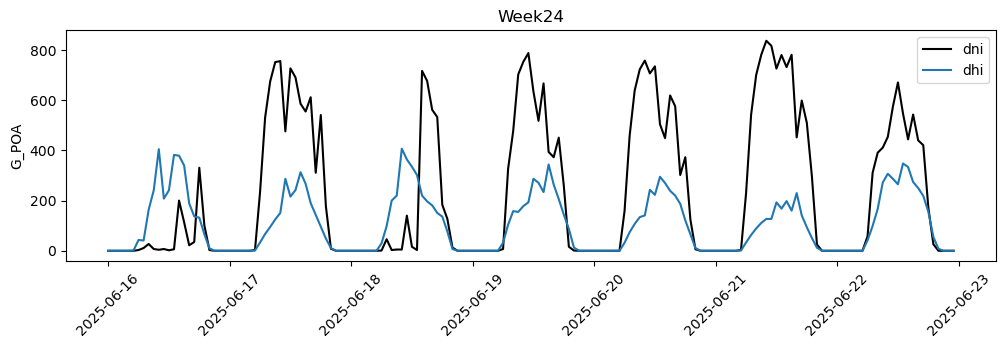

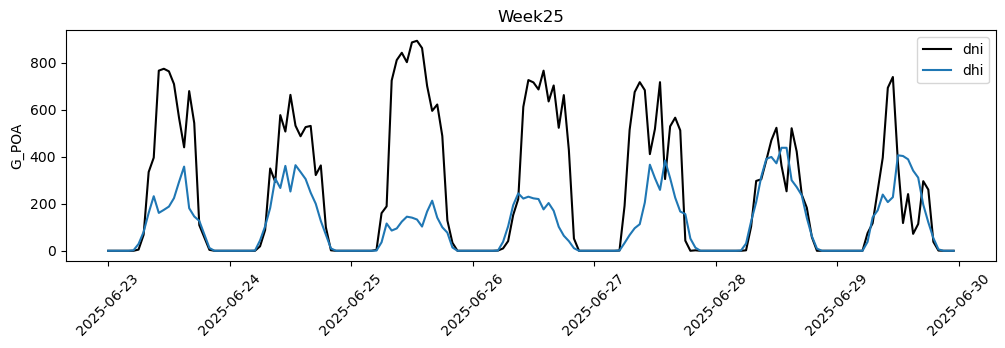

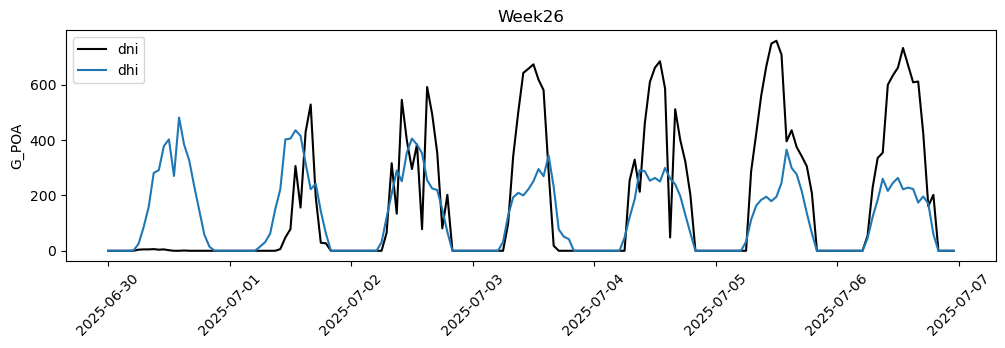

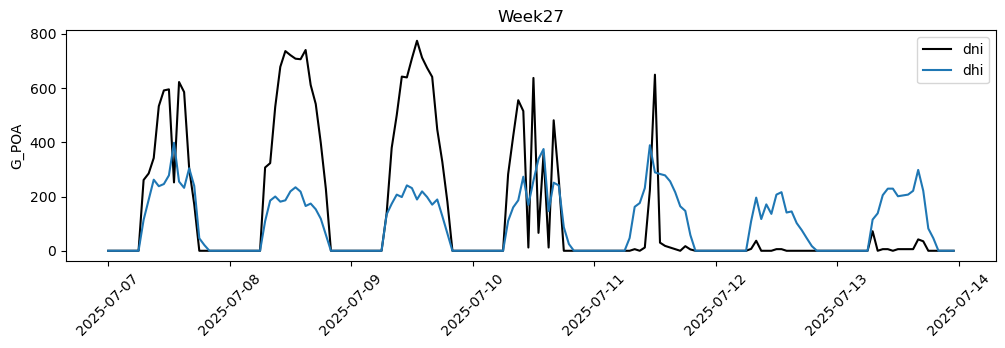

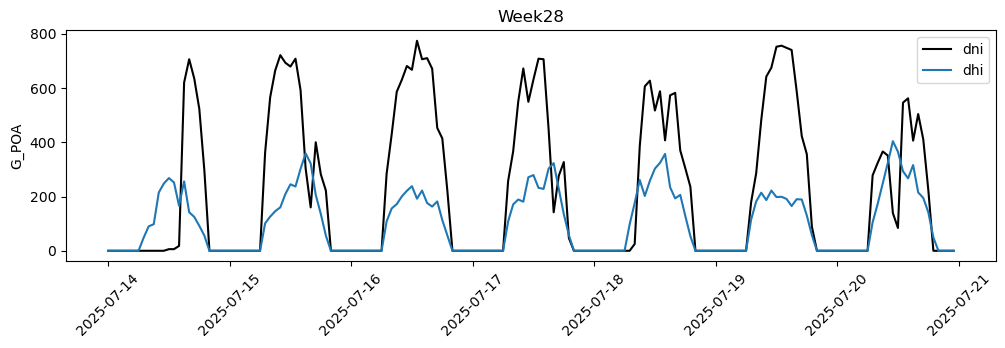

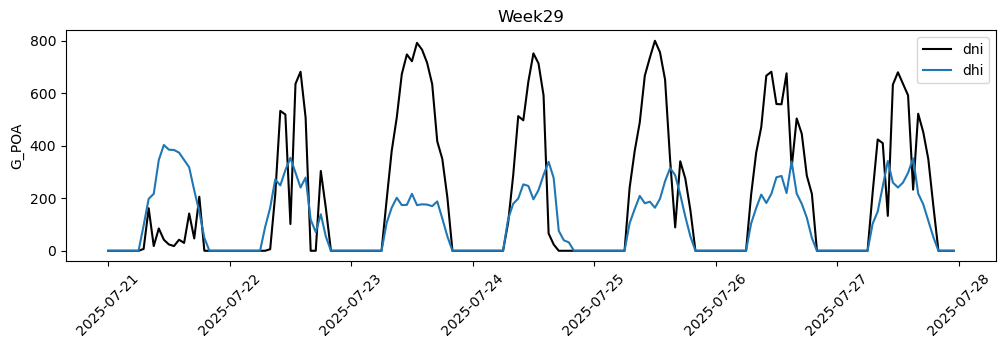

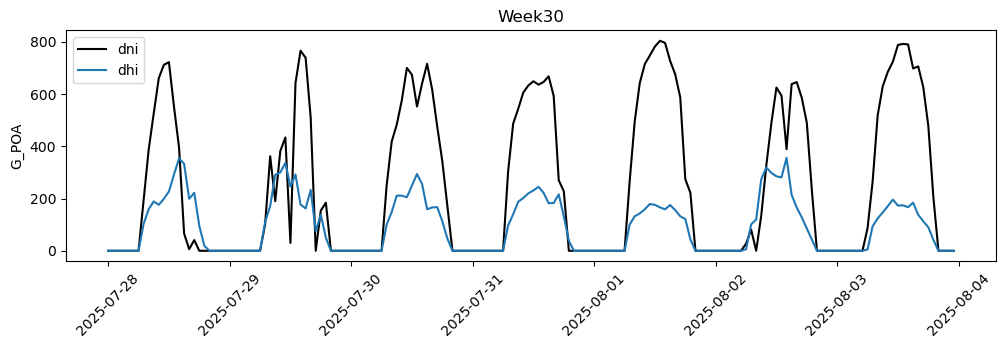

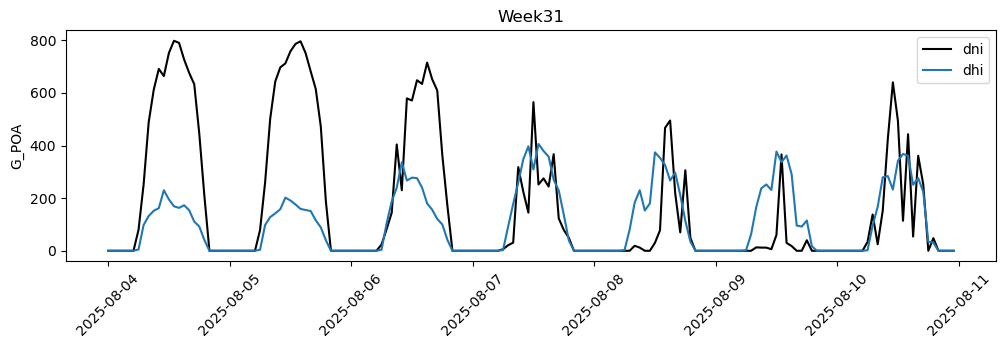

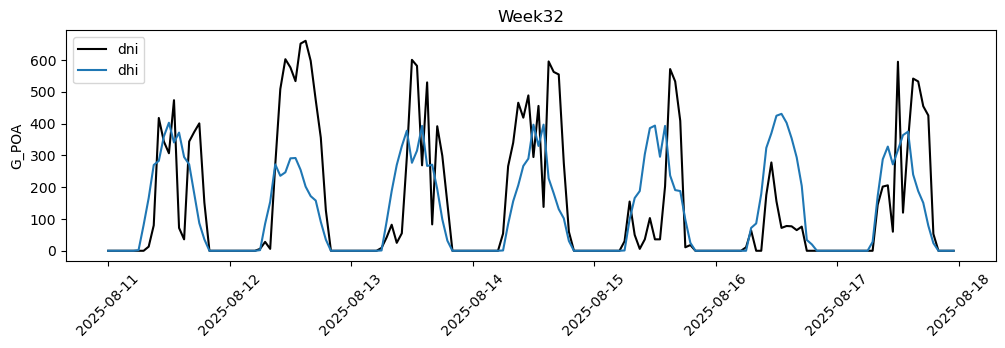

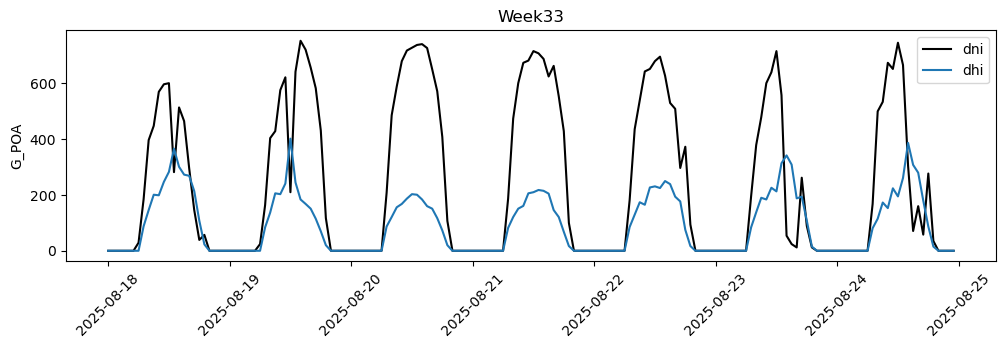

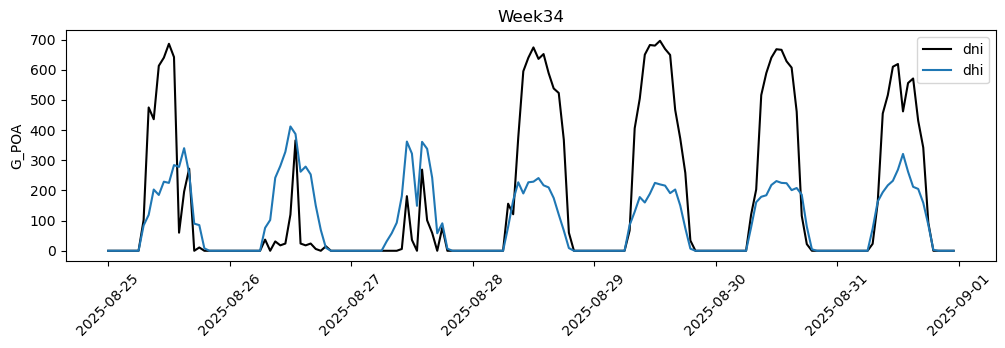

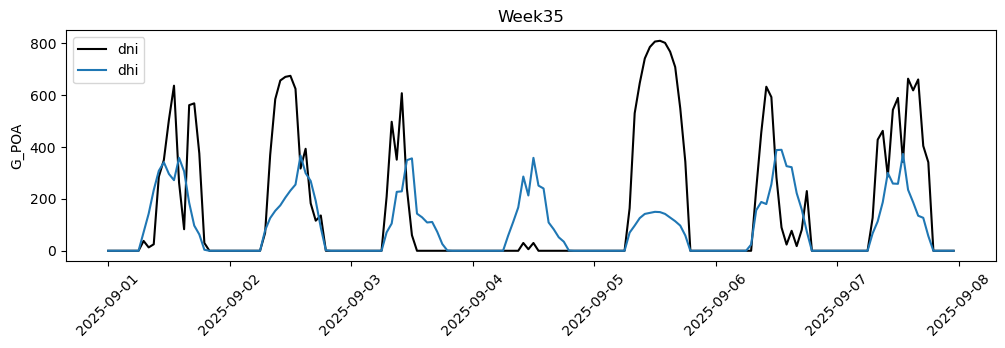

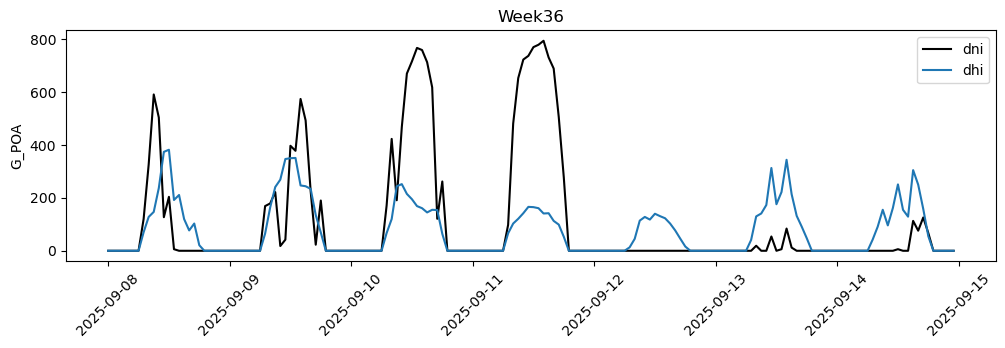

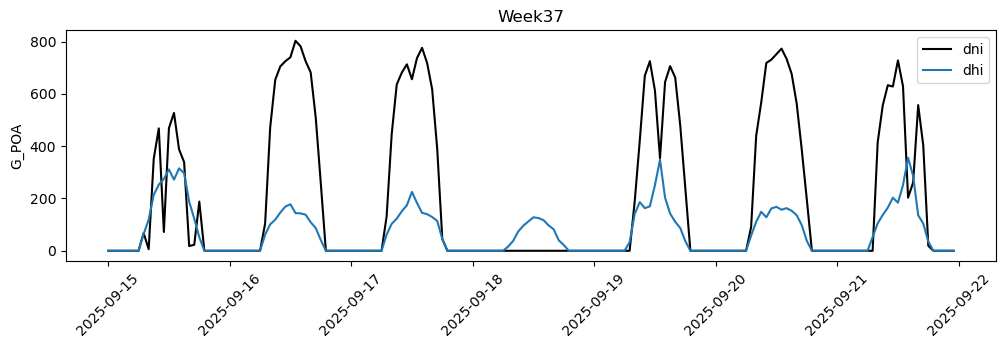

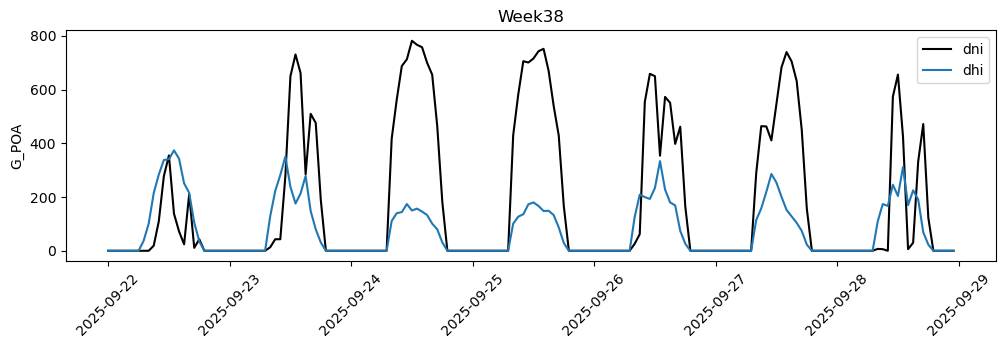

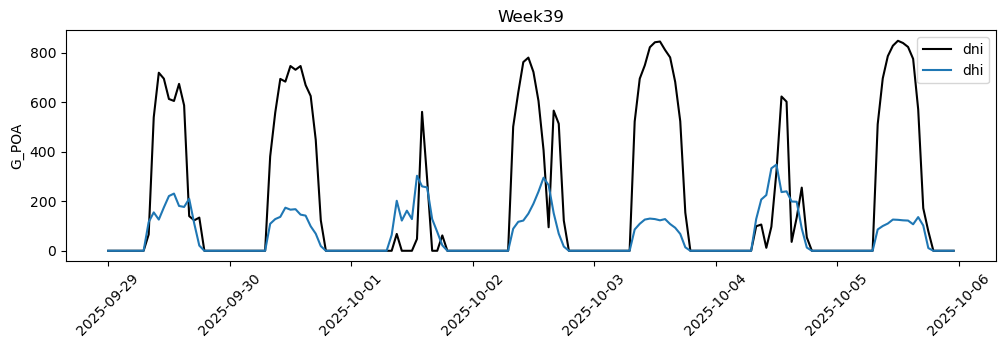

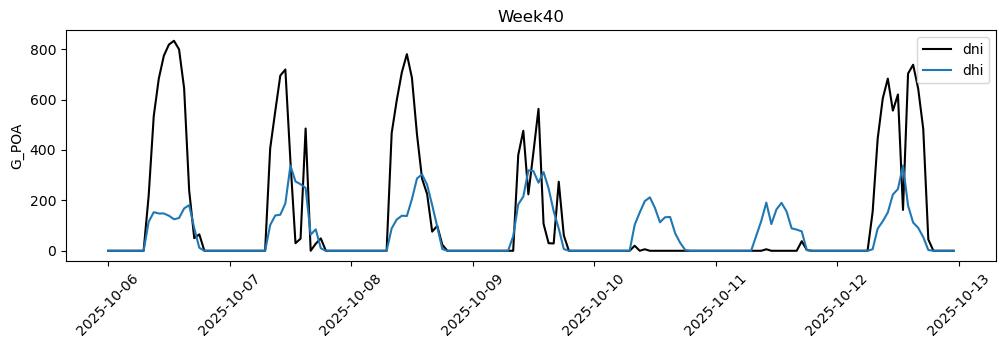

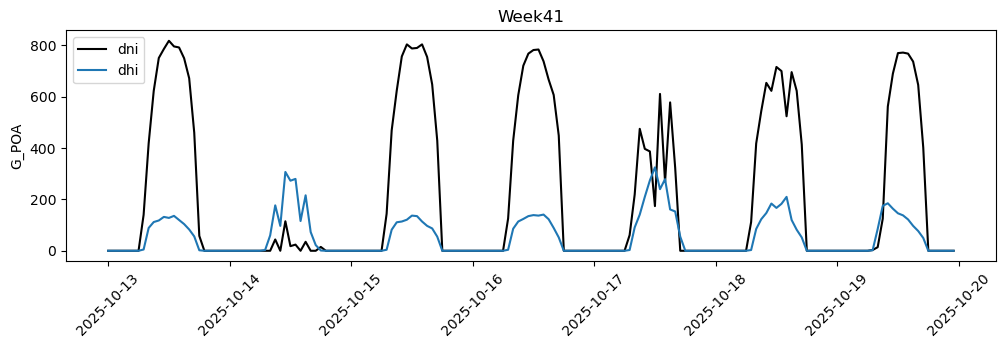

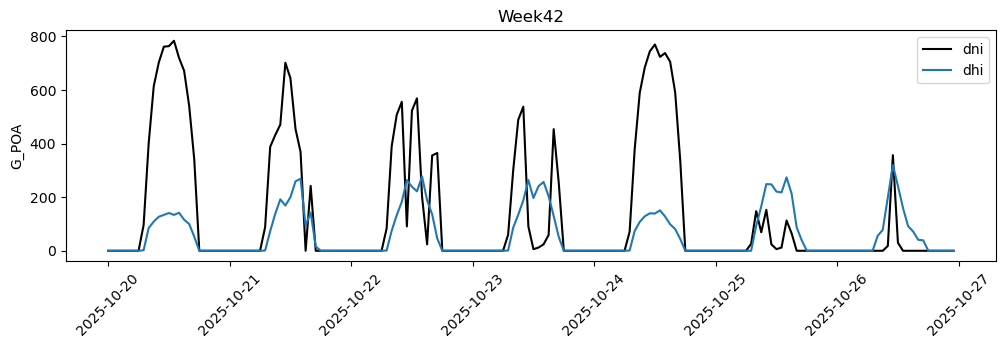

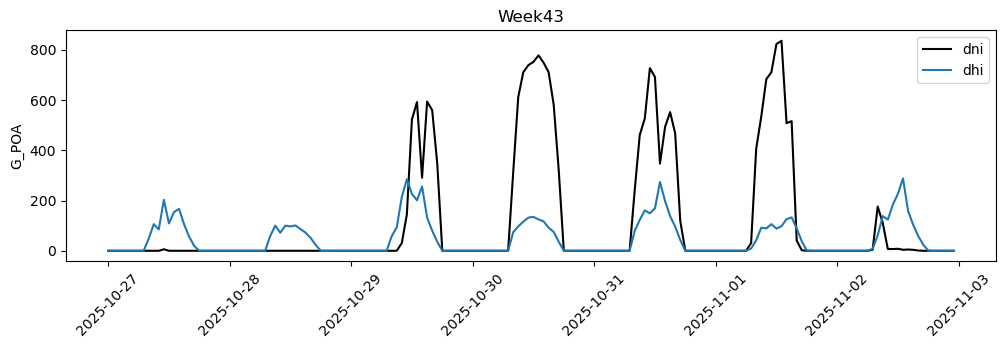

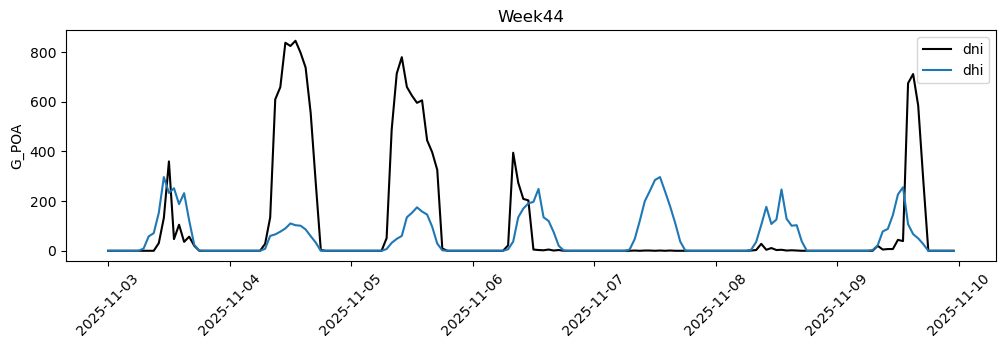

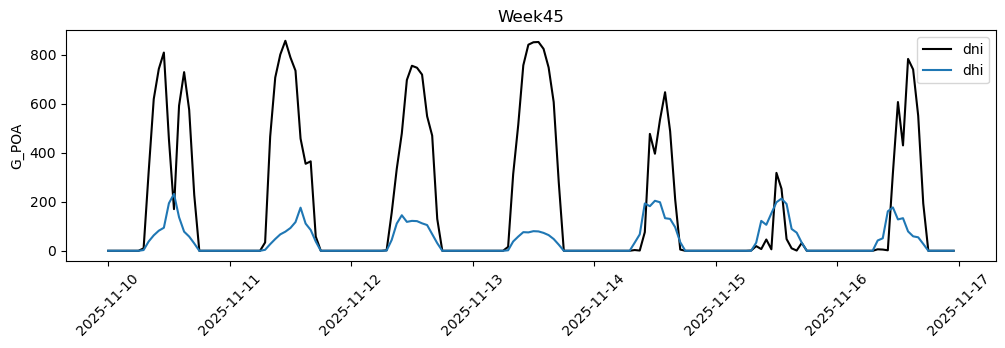

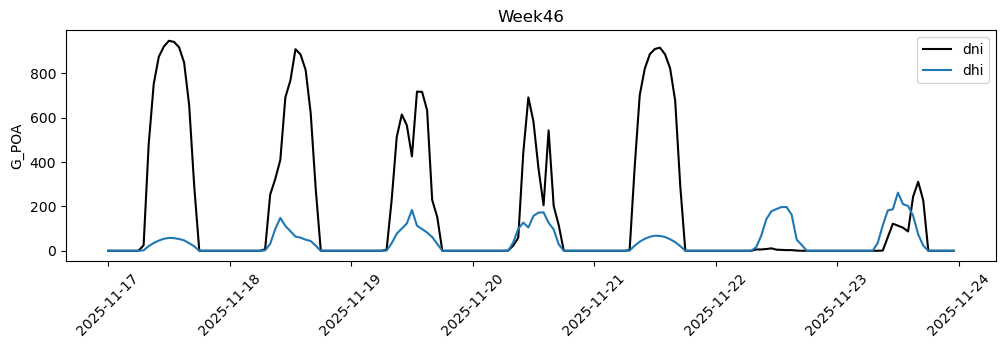

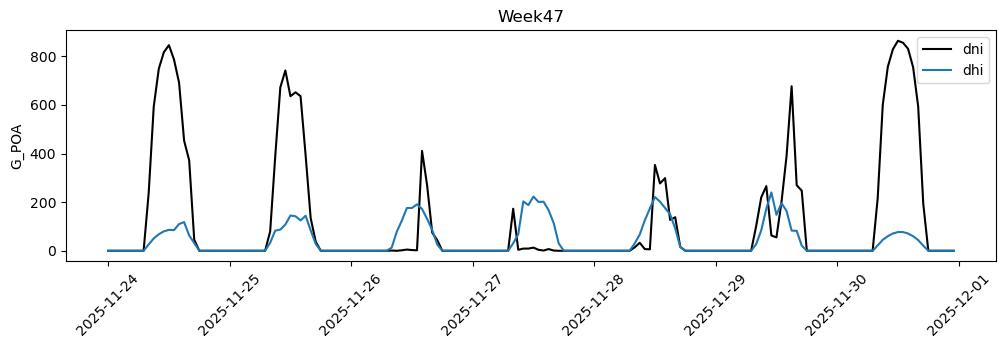

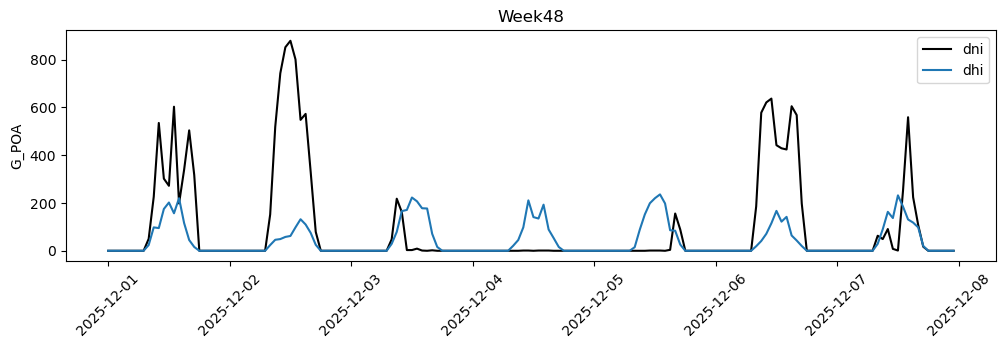

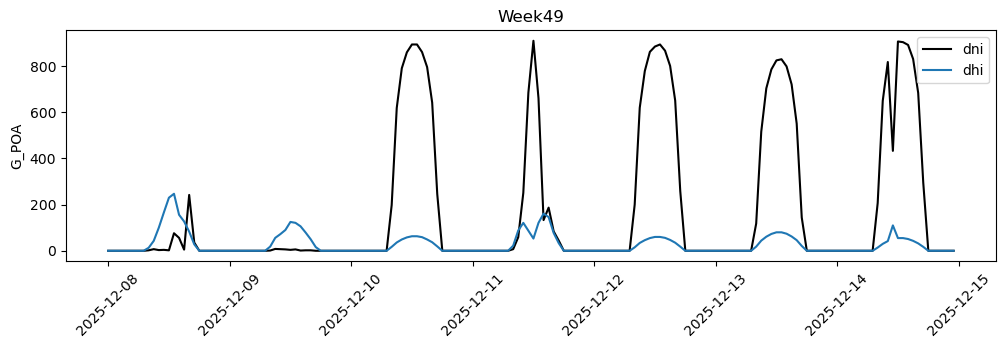

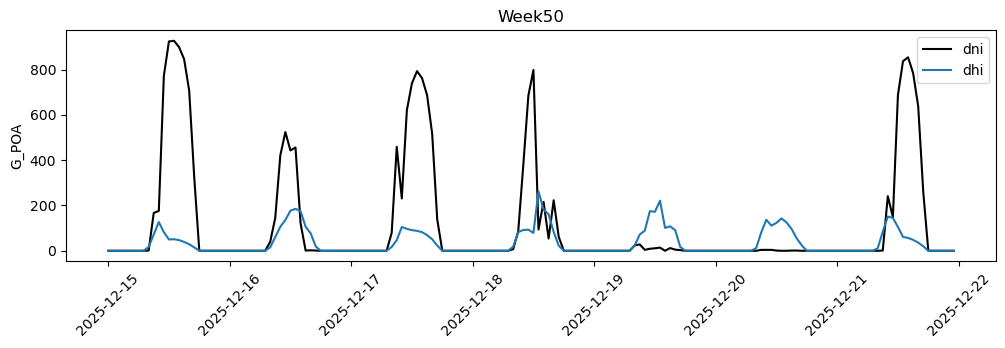

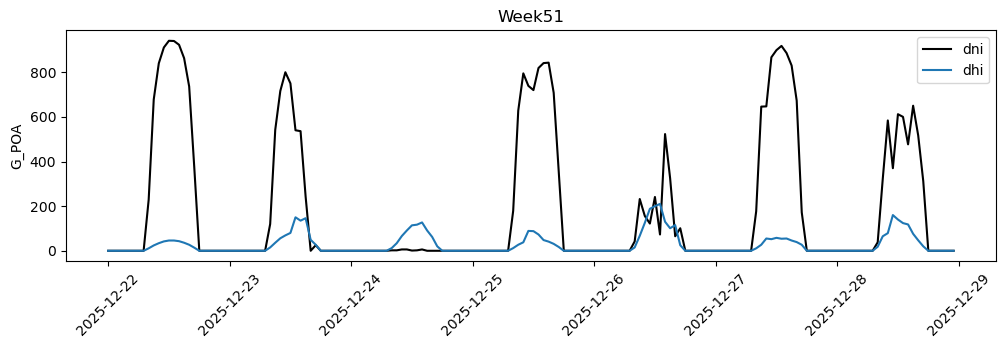

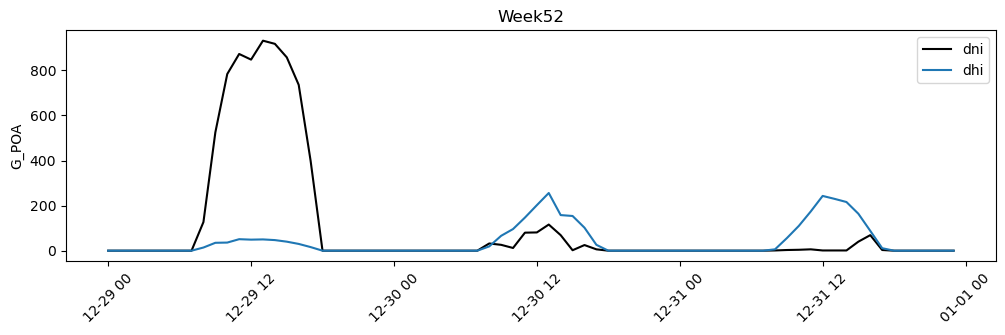

In [3]:
# Plot to visualize data and choose ideal day
weeks = [g for n, g in df.groupby(pd.Grouper(freq='W'))]

plt.rcParams['figure.figsize'] = (12, 3)

for i in range (0, len(weeks)):
    plt.figure()
#    fig, ax = plt.subplots()
    data3 = weeks[i]

    plt.plot(data3.index,data3['DNI (W/m^2)'], 'k', label='dni')
    plt.plot(data3.index,data3['DHI (W/m^2)'], label='dhi')

    plt.legend()
    plt.xticks(rotation = 45) 
    plt.ylabel('G_POA')
    plt.title('Week'+str(i))
    plt.show()

In [4]:
single_day = df.loc['2025-01-24']

In [5]:
single_day.index=single_day.index.tz_localize(-5*3600)

In [6]:
# Richmond
lat=37.517
lon=-77.317

In [7]:
site_loc = pvlib.location.Location(lat, lon)
dni_clear = site_loc.get_clearsky(single_day.index)["dni"]
Cdir = single_day["DNI (W/m^2)"] / dni_clear

In [8]:
single_day["dni_clear"] = dni_clear
single_day["Cdir"] = Cdir

C:\Users\sayala\AppData\Local\Temp\1\ipykernel_12992\2258544034.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  single_day["dni_clear"] = dni_clear
C:\Users\sayala\AppData\Local\Temp\1\ipykernel_12992\2258544034.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  single_day["Cdir"] = Cdir


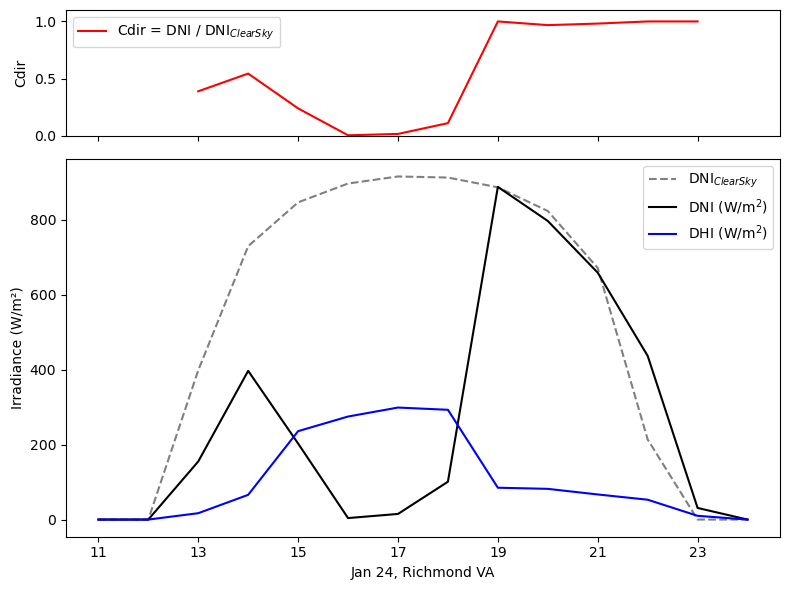

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Define time range for filtering
start_time = "06:00"
end_time = "19:00"

# Filter data based on time range
filtered_data = single_day.between_time(start_time, end_time)

# Cap Cdir values at 1
cdir_capped = np.minimum(filtered_data['Cdir'], 1)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 3]}, figsize=(8, 6))

# Upper subplot (smaller): Cdir
ax1.plot(filtered_data.index, cdir_capped, color="red", label="Cdir = DNI / DNI$_{Clear Sky}$")
ax1.set_ylim(0, 1.1)  # Limit y-axis between 0 and 1.1 for spacing
ax1.set_ylabel("Cdir")
ax1.legend()
ax1.grid(False)

# Lower subplot (larger): Irradiance
ax2.plot(filtered_data.dni_clear, linestyle="dashed", color="gray", label="DNI$_{Clear Sky}$")  # Dashed gray line
ax2.plot(filtered_data['DNI (W/m^2)'], color="black", label="DNI (W/m$^2$)")
ax2.plot(filtered_data['DHI (W/m^2)'], color="blue", label="DHI (W/m$^2$)")

ax2.set_ylabel("Irradiance (W/m²)")
ax2.legend()
ax2.grid(False)



# Formatting
import matplotlib.dates as mdates
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H"))  # Show only hour
ax2.set_xlabel("Jan 24, Richmond VA")
plt.xticks(rotation=0)  # Rotate x-ticks for better readability
plt.tight_layout()  # Adjust layout for better spacing

# Show plot
plt.show()
